# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

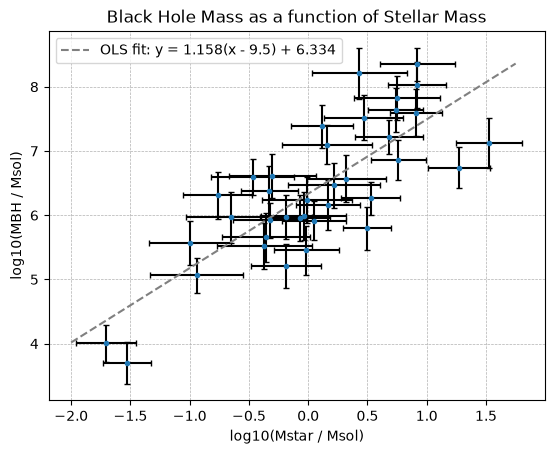

In [366]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt


a = np.genfromtxt('benh7L4.csv', delimiter = ',', skip_header = 1)
x = a.T[0] - 9.5
xerr = a.T[1]
y = a.T[2]
yerr = a.T[3]

plt.errorbar(x, y, xerr = xerr, yerr = yerr, fmt = '.', ecolor = 'black', capsize = 2)
plt.title('Black Hole Mass as a function of Stellar Mass')
plt.xlabel('log10(Mstar / Msol)')
plt.ylabel('log10(MBH / Msol)')
plt.grid(linestyle = '--', linewidth = 0.5)

#Linear Algebra:
X = np.column_stack([np.ones_like(x), x])
coeff = np.linalg.inv(X.T @ X) @ (X.T @ y)
y_intercept = coeff[0]
slope = coeff[1]

x_slope = np.linspace(-2, 1.75, 1000)
y_slope = slope * x_slope + y_intercept

plt.plot(x_slope, y_slope, color = 'grey', linestyle = '--', label = f'OLS fit: y = {slope:.3f}(x - 9.5) + {y_intercept:.3f}')
plt.legend()

In [367]:
#Uncertainty:
model_prediction = slope * x + y_intercept
r = np.sum((y - model_prediction)**2)
s2 = r / (len(x) - 2)

Cov = s2 * np.linalg.inv(X.T @ X)

intercept_err = np.sqrt(Cov[0, 0])
slope_err = np.sqrt(Cov[1, 1])

print(f'Intercept error: {intercept_err:.3f}')
print(f'Slope error: {slope_err:.3f}')

Intercept error: 0.108
Slope error: 0.151


**ANSWER (a few sentences):**

**Slope: 1.158 log10(MBH / Msol) $\pm$ .151 log10(MBH / Msol)**

*An OLS assumes that that there is no error in the x value. This is not the case for this data. Both y and x measurements are uncertain. This additional scatter creates a biased prediction by underestimating the slope value and yielding a lower value than reality. As the scatter (x error) increases, the size of this bias will also increase. This regression model also assumes there isn't any error in the y values. This adds additional bias as the potential shift in location in the y-direction is not accounted for in the model.*

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \tau^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \tau^2 + \sigma_{x,i}^2 & \alpha\,\tau^2 \\
   \alpha\,\tau^2 & \alpha^2\tau^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \tau)$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

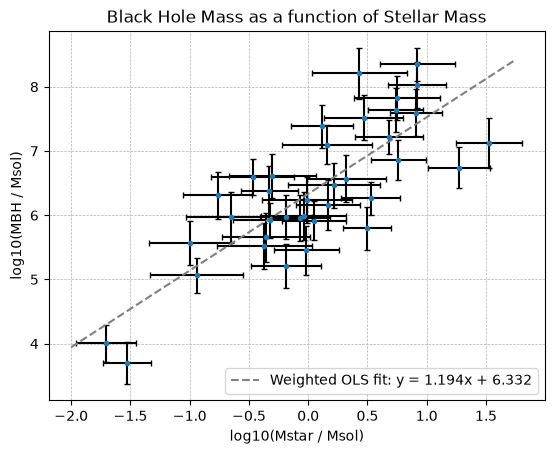

In [368]:
# Part 2: your work here
#Weighted Least Squares
E = np.eye(len(yerr)) * yerr**2
theta_hat = np.linalg.inv(X.T @ np.linalg.inv(E) @ X) @ (X.T @ np.linalg.inv(E) @ y)

plt.errorbar(x, y, xerr = xerr, yerr = yerr, fmt = '.', ecolor = 'black', capsize = 2)
plt.title('Black Hole Mass as a function of Stellar Mass')
plt.xlabel('log10(Mstar / Msol)')
plt.ylabel('log10(MBH / Msol)')
plt.grid(linestyle = '--', linewidth = 0.5)

y_w_intercept = theta_hat[0]
w_slope = theta_hat[1]

x_w_slope = np.linspace(-2, 1.75, 1000)
y_w_slope = w_slope * x_w_slope + y_w_intercept

plt.plot(x_w_slope, y_w_slope, color = 'grey', linestyle = '--', label = f'Weighted OLS fit: y = {w_slope:.3f}x + {y_w_intercept:.3f}')
plt.legend()

In [369]:
w_cov = np.linalg.inv(X.T @ np.linalg.inv(E) @ X)
w_intercept_err = np.sqrt(w_cov[0, 0])
w_slope_err = np.sqrt(w_cov[1, 1])

print(w_intercept_err)
print(w_slope_err)

0.054379748569421446
0.07408564158216462


In [370]:
#Orthogonal Distance Regression
import scipy.odr

def f(B, x):
    return B[0] * x + B[1]

linear = scipy.odr.Model(f)
mydata = scipy.odr.Data(x, y, wd = 1/(xerr**2), we = 1/(yerr**2))
myodr = scipy.odr.ODR(mydata, linear, beta0 = [slope, y_intercept])
myoutput = myodr.run()
myoutput.pprint()

Beta: [1.51432522 6.24032984]
Beta Std Error: [0.16472632 0.1171133 ]
Beta Covariance: [[ 0.0168795  -0.00161696]
 [-0.00161696  0.00853191]]
Residual Variance: 1.6075569453377951
Inverse Condition #: 0.7473216579597673
Reason(s) for Halting:
  Sum of squares convergence


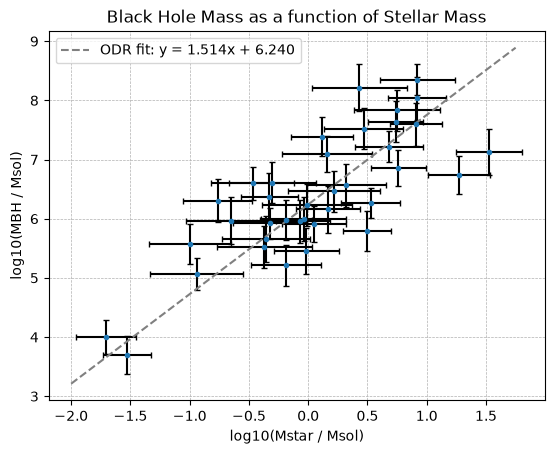

In [371]:
y_odr_intercept = 6.24032984
odr_slope = 1.51432522
x_odr_slope = np.linspace(-2, 1.75, 1000)
y_odr_slope = odr_slope * x_odr_slope + y_odr_intercept


plt.errorbar(x, y, xerr = xerr, yerr = yerr, fmt = '.', ecolor = 'black', capsize = 2)
plt.title('Black Hole Mass as a function of Stellar Mass')
plt.xlabel('log10(Mstar / Msol)')
plt.ylabel('log10(MBH / Msol)')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.plot(x_odr_slope, y_odr_slope, color = 'grey', linestyle = '--', label = f'ODR fit: y = {odr_slope:.3f}x + {y_odr_intercept:.3f}')
plt.legend()

The ODR method assumes that all of the scatter present within the data comes from the error from both the x and y variables. To account for this, an ODR regression model minimizes the weighted perpindicular distance between both the x and y variables and errors. This assumes there isn't any intrinsic scatter within the data. This however, is not true. There is still additional intrinsic scatter from the data (not every AGN will produce similar results) which will cause bias for the ODR. 

In [372]:
#Generative Model:

import scipy.optimize as so

def neg2logL_gen(p, x, y, sx, sy):
    alpha, beta, log_sint, mu, log_sig_pop = p
    sint2, tau2 = np.exp(2 * log_sint), np.exp(2 * log_sig_pop)
    dx, dy = x - mu, y - (alpha * (mu - 9.5) + beta)
    s11 = tau2 + sx**2
    s22 = alpha**2 * tau2 + sint2 + sy**2
    s12 = alpha * tau2
    det = s11 * s22 - s12**2
    quad = (s22 * dx**2 - 2 * s12 * dx * dy + s11 * dy**2) / det
    return np.sum(np.log(det) + quad)

theta0 = [odr_slope, y_odr_intercept, np.log(1.608), 0, np.log(np.std(x))]

result = so.minimize(neg2logL_gen, x0 = theta0, args = (x, y, xerr, yerr), method = 'Nelder-Mead')
result.x

array([ 1.35574194, 19.15980574, -0.90929072,  0.08899042, -0.40874243])

In [373]:
print(np.exp(result.x[2]))
print(np.exp(result.x[4]))

0.4028098265219929
0.6644853645040193


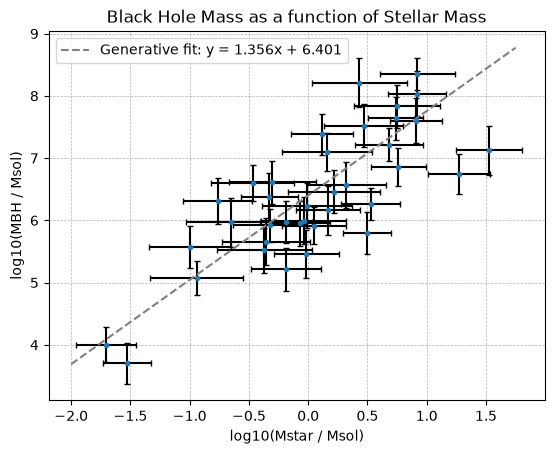

In [374]:
a_opt, B_opt, log_intr_s_opt, mu_opt, log_tau_opt = result.x  

x_gen_slope = np.linspace(-2, 1.75, 1000)
gen_intercept = a_opt * (mu_opt - 9.5) + B_opt
y_gen_slope = a_opt * x_gen_slope + gen_intercept

plt.errorbar(x, y, xerr = xerr, yerr = yerr, fmt = '.', ecolor = 'black', capsize = 2)
plt.title('Black Hole Mass as a function of Stellar Mass')
plt.xlabel('log10(Mstar / Msol)')
plt.ylabel('log10(MBH / Msol)')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.plot(x_gen_slope, y_gen_slope, color = 'grey', linestyle = '--', label = f'Generative fit: y = {a_opt:.3f}x + {gen_intercept:.3f}')
plt.legend()

In [375]:
#Gen uncertainties: 
import numdifftools as nd

H = nd.Hessian(lambda p: neg2logL_gen(p, x, y, xerr, yerr))(result.x)
Cov = 2 * np.linalg.inv(H)
uncertainty = np.sqrt(np.diag(Cov))

sigma_intr_uncert = np.exp(log_intr_s_opt) * uncertainty[2]
Tau_uncert = np.exp(log_tau_opt) * uncertainty[4]

uncertainty = [uncertainty[0], uncertainty[1], sigma_intr_uncert, uncertainty[3], Tau_uncert]

print(uncertainty)

[np.float64(0.17567578888774063), np.float64(1.651302132375617), np.float64(0.12311172870496383), np.float64(0.11992840783131771), np.float64(0.09037708644289888)]


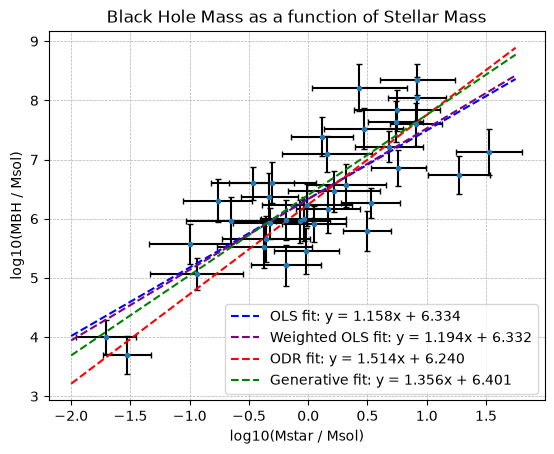

In [376]:
#Comparison of Models
plt.errorbar(x, y, xerr = xerr, yerr = yerr, fmt = '.', ecolor = 'black', capsize = 2)
plt.title('Black Hole Mass as a function of Stellar Mass')
plt.xlabel('log10(Mstar / Msol)')
plt.ylabel('log10(MBH / Msol)')
plt.grid(linestyle = '--', linewidth = 0.5)

plt.plot(x_slope, y_slope, color = 'blue', linestyle = '--', label = f'OLS fit: y = {slope:.3f}x + {y_intercept:.3f}')
plt.plot(x_w_slope, y_w_slope, color = 'purple', linestyle = '--', label = f'Weighted OLS fit: y = {w_slope:.3f}x + {y_w_intercept:.3f}')
plt.plot(x_odr_slope, y_odr_slope, color = 'red', linestyle = '--', label = f'ODR fit: y = {odr_slope:.3f}x + {y_odr_intercept:.3f}')
plt.plot(x_gen_slope, y_gen_slope, color = 'green', linestyle = '--', label = f'Generative fit: y = {a_opt:.3f}x + {gen_intercept:.3f}')
plt.legend()

The OLS fit underestimates the slope. This is as the model assumes there is no scatter within the data. The scatter that exists drags the slope down as the points are scattered and not fully aligned as the model assumes. The weighted OLS has a sharper slope as it takes the error in the y direction into consideration. It is still an underestimate as it doesn't account for the large varience from the xerrors. The ODR fit accounts for the scatter in the x direction by minimizing the distance between the scatter in the x and y direction. This overestimates the slope as it doesn't take the intrinsic scatter of the black hole mass and instead assumes that all of the scatter is coming from the errors alone. The generative fit surpasses all of these models by taking the errors in both the x and y direction into consideration and by assuming there is an intrinsic scatter to the data. 

**FINAL ANSWER:** $\alpha = $ 1.356 $\pm$ .124 , $\beta = $ 19.160 $\pm$ 1.168 , $\sigma_{\rm int} = $ .403 $\pm$ .087 dex

**Justification and uncertainty method (a short paragraph):**

*I chose to use the generative line results as this method accounts for the errors present in both the x and y direction while also taking the intrinsic scatter of the black hole into consideration. This generative method accounts for the assumptions that the OLS weighted OLS and ODR methods break down on. Additionally, as the OLS is underreporting the slope and the ODR is overestimating slope, I am more confident that my generative method was down correctly as it resulted in a value between these two regressors.*

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

To verify my work I:
1) Closure: I simulated dataset with my own truth. I could use this by comparing the values directly to the answer to see how my model held up. A failure for this check would be if my model found a predicted value that was outside three sigma of the provided errors. This would allow me to see if the value was significantly larger (and by extension my model was providing incorrect answers).
2) Bias and Efficiency: By making a monte carlo simulation of my data I could visually see how biased my estimators were and whether they were producing unexpected values. A failure would be if my generative model was more than .01 biased. If this was the case, it would mean I had lots of systematic uncertainties in my methodology bringing the generative model down. Additionally, this check would fail if my other three estimators were incorrectly biased. Both my OLS and WLS should have most of the data biased such that it is under reporting the slope while the ODR model should be biased such that it over reports the slope.
3) Coverage: By checking that my generative model contained the truth ~68% of the time would mean that I was performign the uncertainty caluclation correctly. A failure would be if my generative model didn't cover each value by more than ~+-3%. This wouls mean that my model was significantly incorrect in yielding the proper answer.
4) Sensitivity: I checked three different things, overreporting errors, drawing from a uniform distribution, and checking if the intrinsic scatter was zero. A failure for the 50% errors would be if I created a plot with overestimated errors and it created a steeper model. Since the errors flatten the slope, increasing the errors should result in an overprediction of how much the data is flattened. By checking a uniform distribution, the model should become more biased since it doesn't depend on u and T anymore. A failure for this check would be if I get values for tau and mu. Since the model doesn't depend on these values, getting large values for them will skew the data. For my intrinsic scatter plot, a failure would be if my mu and tau values didn't become an order of magnitude smaller. Since I don't have any intrinsic scatter, my model should choose smalelr mu and tau values to compensate for the decrease in scatter. 

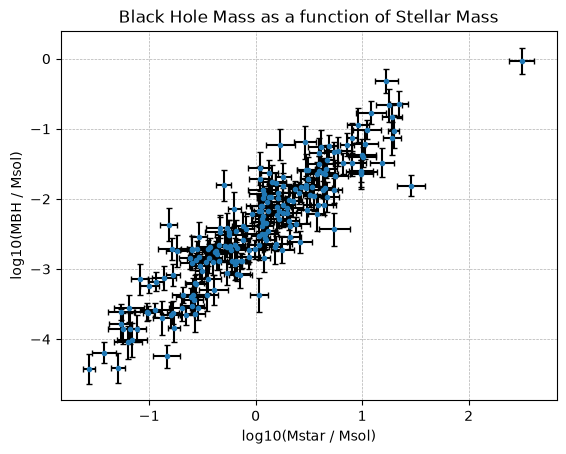

In [377]:
#Closure
np.random.seed(457)

# Choose truth
alpha_true = 1.1
beta_true = 8.0
sigma_int_true = 0.3

mu_true = 0
tau_true = 0.7

N = 200

# latent (true) values
x_true = np.random.normal(mu_true, tau_true, N)

y_true = (
    alpha_true * (x_true - 9.5)
    + beta_true
    + np.random.normal(0, sigma_int_true, N)
)

# measurement uncertainties
xerr = np.random.uniform(0.05, 0.15, N)
yerr = np.random.uniform(0.10, 0.25, N)

# observed values
x = x_true + np.random.normal(0, xerr)
y = y_true + np.random.normal(0, yerr)

plt.errorbar(x, y, xerr = xerr, yerr = yerr, fmt = '.', ecolor = 'black', capsize = 2)
plt.title('Black Hole Mass as a function of Stellar Mass')
plt.xlabel('log10(Mstar / Msol)')
plt.ylabel('log10(MBH / Msol)')
plt.grid(linestyle = '--', linewidth = 0.5)

In [378]:
theta0 = [1.05, 7.9, np.log(0.3), 0, np.log(.7)]

result = so.minimize(neg2logL_gen, x0 = theta0, args = (x, y, xerr, yerr), method = 'Nelder-Mead')
result.x

array([ 1.16494188e+00,  8.64565970e+00, -1.38302966e+00, -2.70084345e-03,
       -4.34329473e-01])

In [379]:
H = nd.Hessian(lambda p: neg2logL_gen(p, x, y, xerr, yerr))(result.x)
Cov = 2 * np.linalg.inv(H)
uncertainty = np.sqrt(np.diag(Cov))

sigma_intr_uncert = np.exp(log_intr_s_opt) * uncertainty[2]
Tau_uncert = np.exp(log_tau_opt) * uncertainty[4]

uncertainty = [uncertainty[0], uncertainty[1], sigma_intr_uncert, uncertainty[3], Tau_uncert]

print(f'Alpha: {result.x[0]:.3f} \u00B1 {uncertainty[0]:.3f}')
print(f'Beta: {result.x[1]:.3f} \u00B1 {uncertainty[1]:.3f}')
print(f'Intrinsic Scatter: {np.exp(result.x[2]):.3f} \u00B1 {uncertainty[2]:.3f}')

Alpha: 1.165 ± 0.037
Beta: 8.646 ± 0.353
Intrinsic Scatter: 0.251 ± 0.036


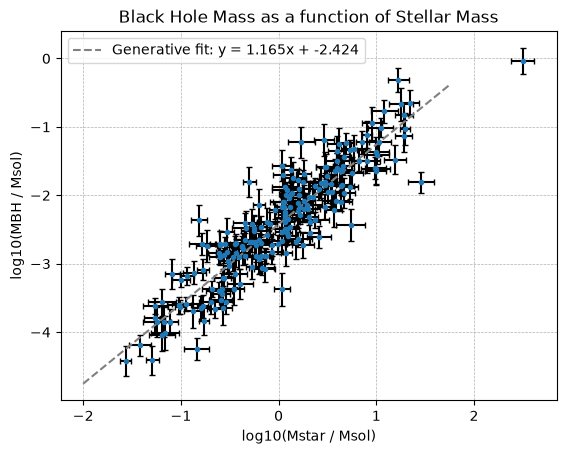

In [380]:
a_opt, B_opt, log_intr_s_opt, mu_opt, log_tau_opt = result.x  

x_gen_slope = np.linspace(-2, 1.75, 1000)
gen_intercept = a_opt * (mu_opt - 9.5) + B_opt
y_gen_slope = a_opt * x_gen_slope + gen_intercept

plt.errorbar(x, y, xerr = xerr, yerr = yerr, fmt = '.', ecolor = 'black', capsize = 2)
plt.title('Black Hole Mass as a function of Stellar Mass')
plt.xlabel('log10(Mstar / Msol)')
plt.ylabel('log10(MBH / Msol)')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.plot(x_gen_slope, y_gen_slope, color = 'grey', linestyle = '--', label = f'Generative fit: y = {a_opt:.3f}x + {gen_intercept:.3f}')
plt.legend()

In [381]:
#Monte Carlo
def simulate_dataset(N):

    x_true = np.random.normal(mu_true, tau_true, N)

    y_true = (
        alpha_true * (x_true - 9.5)
        + beta_true
        + np.random.normal(0, sigma_int_true, N)
    )

    xerr = np.random.uniform(0.05, 0.15, N)
    yerr = np.random.uniform(0.10, 0.25, N)

    x = x_true + np.random.normal(0, xerr)
    y = y_true + np.random.normal(0, yerr)

    return x, y, xerr, yerr

def fit_generative(xdata, ydata, xerrsim, yerrsim):

    theta0 = [
        1.0,
        8.0,
        np.log(0.3),
        np.mean(xdata),
        np.log(np.std(xdata))
    ]

    result = so.minimize(
        neg2logL_gen,
        x0=theta0,
        args=(xdata, ydata, xerr, yerr),
        method='Nelder-Mead'
    )

    a_opt, B_opt, log_intr_s_opt, mu_opt, log_tau_opt = result.x  

    H = nd.Hessian(lambda p: neg2logL_gen(p, xdata, ydata, xerrsim, yerrsim))(result.x)
    Cov = 2 * np.linalg.inv(H)
    uncertainty = np.sqrt(np.diag(Cov)) #* 1.4

    sigma_intr_uncert = np.exp(log_intr_s_opt) * uncertainty[2]
    Tau_uncert = np.exp(log_tau_opt) * uncertainty[4]

    uncertainty = [uncertainty[0], uncertainty[1], sigma_intr_uncert, uncertainty[3], Tau_uncert]

    return result.x, uncertainty

def fit_OLS(x, y):
    X = np.column_stack([np.ones_like(x), x])
    coeff = np.linalg.inv(X.T @ X) @ (X.T @ y)
    y_intercept = coeff[0]
    slope = coeff[1]
    
    model_prediction = slope * x + y_intercept
    r = np.sum((y - model_prediction)**2)
    s2 = r / (len(x) - 2)
    Cov = s2 * np.linalg.inv(X.T @ X)
    intercept_err = np.sqrt(Cov[0, 0])
    slope_err = np.sqrt(Cov[1, 1])

    return slope, y_intercept, intercept_err, slope_err

def fit_WOLS(x, y, yerr):
    X = np.column_stack([np.ones_like(x), x])
    E = np.eye(len(yerr)) * yerr**2
    theta_hat = np.linalg.inv(X.T @ np.linalg.inv(E) @ X) @ (X.T @ np.linalg.inv(E) @ y)
    y_w_intercept = theta_hat[0]
    w_slope = theta_hat[1]

    w_cov = np.linalg.inv(X.T @ np.linalg.inv(E) @ X)
    w_intercept_err = np.sqrt(w_cov[0, 0])
    w_slope_err = np.sqrt(w_cov[1, 1])
    
    return w_slope, y_w_intercept, w_intercept_err, w_slope_err

def fit_ODR(x, y, xerr, yerr, slope, y_intercept):
    linear = scipy.odr.Model(f)
    mydata = scipy.odr.Data(x, y, wd = 1/(xerr**2), we = 1/(yerr**2))
    myodr = scipy.odr.ODR(mydata, linear, beta0 = [slope, y_intercept])
    myoutput = myodr.run()
    alph_err = np.sqrt(myoutput.cov_beta[0, 0])
    beta_err = np.sqrt(myoutput.cov_beta[1, 1])
    return myoutput.beta[0], myoutput.beta[1], alph_err, beta_err

#N_values = [25, 50, 100, 200, 500]

#Nmc = 500

gen_slopes = []
OLS_slopes = []
WOLS_slopes = []
ODR_slopes = []

#for N in N_values:  

for i in range(2000):

    x, y, xerr, yerr = simulate_dataset(150)

    gen_fit = fit_generative(x, y, xerr, yerr)

    OLS_fit = fit_OLS(x, y)
    WOLS_fit = fit_WOLS(x, y, yerr)
    ODR_fit = fit_ODR(x, y, xerr, yerr, WOLS_fit[0], WOLS_fit[1])

    gen_slopes.append(gen_fit)
    OLS_slopes.append(OLS_fit)
    WOLS_slopes.append(WOLS_fit)
    ODR_slopes.append(ODR_fit)
        


In [382]:
gen_slopes = np.array(gen_slopes)
OLS_slopes = np.array(OLS_slopes)
WOLS_slopes = np.array(WOLS_slopes)
ODR_slopes = np.array(ODR_slopes)

In [383]:
gen_bias = gen_slopes[:, 0, 0] - alpha_true
OLS_bias = OLS_slopes.T[0] - alpha_true
WOLS_bias = WOLS_slopes.T[0] - alpha_true
ODR_bias = ODR_slopes.T[0] - alpha_true

gen_var = np.var(gen_slopes[:, 0, 0])
OLS_var = np.var(OLS_slopes.T[0])
WOLS_var = np.var(WOLS_slopes.T[0])
ODR_var = np.var(ODR_slopes.T[0])

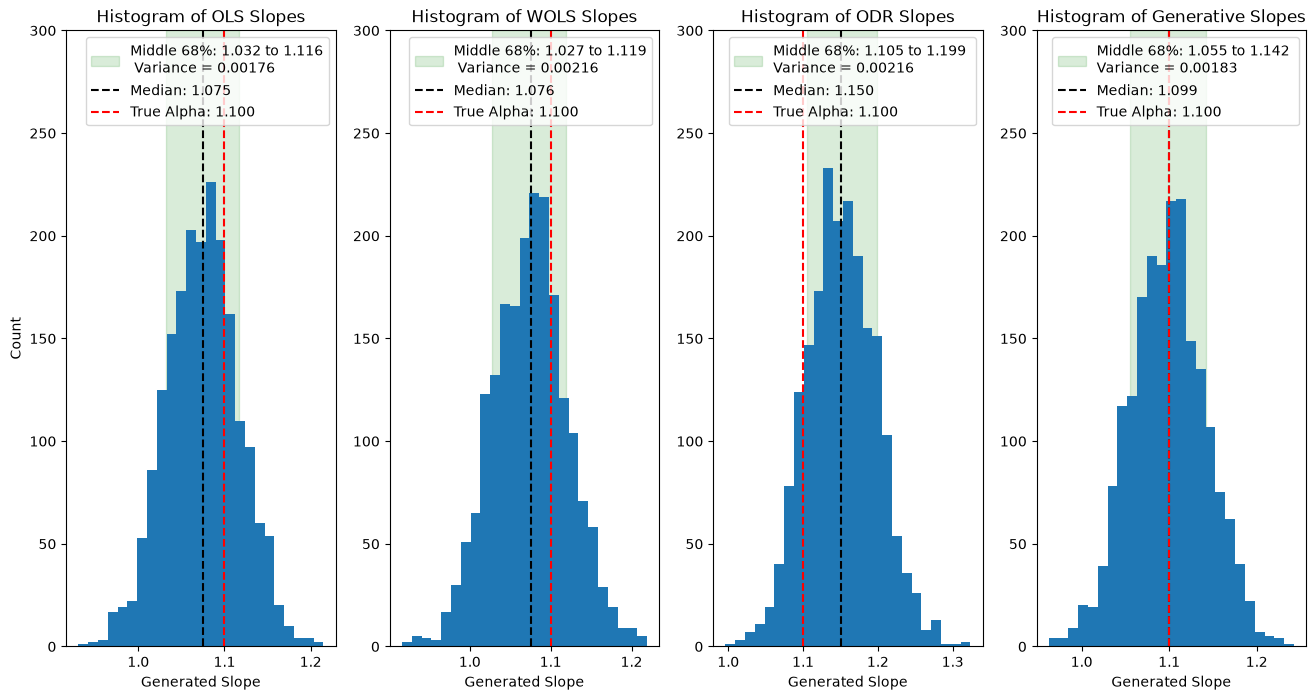

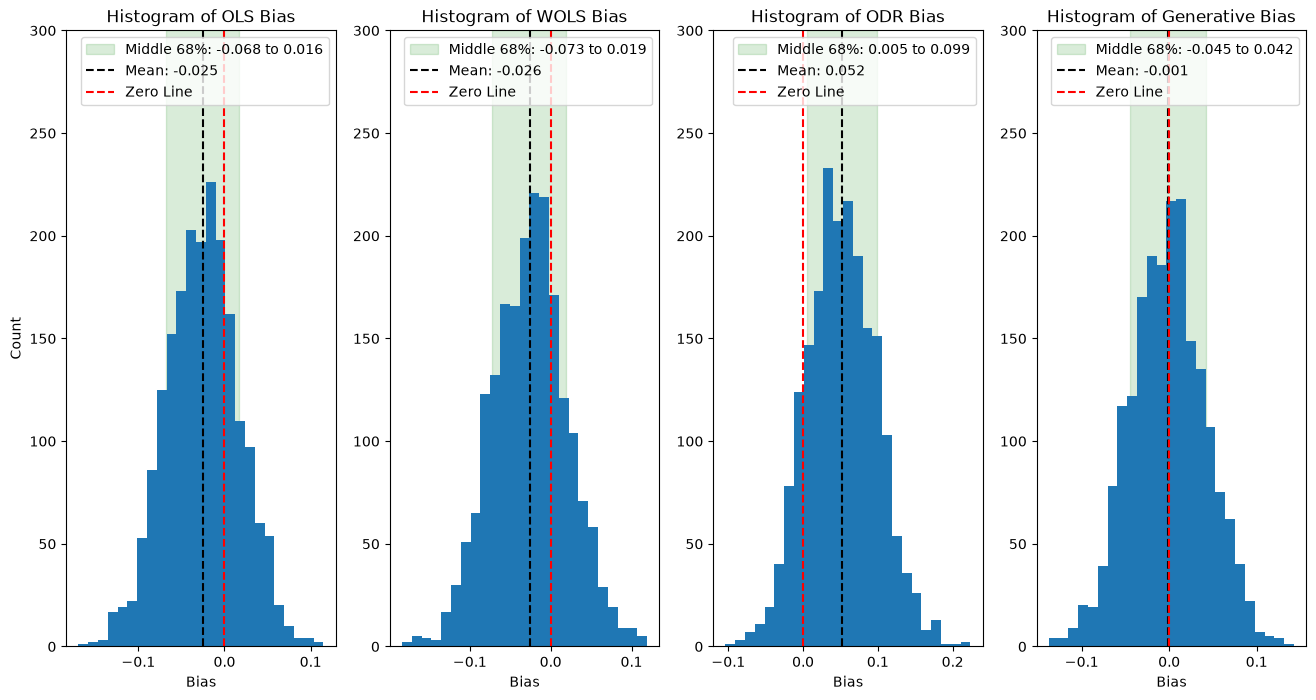

In [384]:
plt.figure(1, figsize = (16, 8))
plt.subplot(1, 4, 1)
med = np.median(OLS_slopes.T[0])

hi, lo = np.percentile(OLS_slopes.T[0], [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f}\n Variance = {OLS_var:.5f}')

plt.hist(OLS_slopes.T[0], bins = 25)
plt.title('Histogram of OLS Slopes')
plt.ylabel('Count')
plt.xlabel('Generated Slope')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Median: {med:.3f}')
plt.vlines(alpha_true, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'True Alpha: {alpha_true:.3f}')
plt.ylim([0, 300])
plt.legend()

plt.subplot(1, 4, 2)

hi, lo = np.percentile(WOLS_slopes.T[0], [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f}\n Variance = {WOLS_var:.5f}')

med = np.median(WOLS_slopes.T[0])
plt.hist(WOLS_slopes.T[0], bins = 25)
plt.title('Histogram of WOLS Slopes')
plt.xlabel('Generated Slope')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Median: {med:.3f}')
plt.vlines(alpha_true, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'True Alpha: {alpha_true:.3f}')
plt.ylim([0, 300])
plt.legend()

plt.subplot(1, 4, 3)

hi, lo = np.percentile(ODR_slopes.T[0], [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f} \nVariance = {ODR_var:.5f}')

med = np.median(ODR_slopes.T[0])
plt.hist(ODR_slopes.T[0], bins = 25)
plt.title('Histogram of ODR Slopes')
plt.xlabel('Generated Slope')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Median: {med:.3f}')
plt.vlines(alpha_true, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'True Alpha: {alpha_true:.3f}')
plt.ylim([0, 300])
plt.legend()

plt.subplot(1, 4, 4)

hi, lo = np.percentile(gen_slopes[:, 0, 0], [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f} \nVariance = {gen_var:.5f}')

med = np.median(gen_slopes[:, 0, 0])
plt.hist(gen_slopes[:, 0, 0], bins = 25)
plt.title('Histogram of Generative Slopes')
plt.xlabel('Generated Slope')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Median: {med:.3f}')
plt.vlines(alpha_true, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'True Alpha: {alpha_true:.3f}')
plt.ylim([0, 300])
plt.legend()



plt.figure(2, figsize = (16, 8))
plt.subplot(1, 4, 1)

hi, lo = np.percentile(OLS_bias, [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f}')

med = np.mean(OLS_bias)
plt.hist(OLS_bias, bins = 25)
plt.title('Histogram of OLS Bias')
plt.ylabel('Count')
plt.xlabel('Bias')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Mean: {med:.3f}')
plt.vlines(0, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'Zero Line')
plt.ylim([0, 300])
plt.legend()

plt.subplot(1, 4, 2)

hi, lo = np.percentile(WOLS_bias, [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f}')

med = np.mean(WOLS_bias)
plt.hist(WOLS_bias, bins = 25)
plt.title('Histogram of WOLS Bias')
plt.xlabel('Bias')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Mean: {med:.3f}')
plt.vlines(0, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'Zero Line')
plt.ylim([0, 300])
plt.legend()

plt.subplot(1, 4, 3)

hi, lo = np.percentile(ODR_bias, [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f}')

med = np.mean(ODR_bias)
plt.hist(ODR_bias, bins = 25)
plt.title('Histogram of ODR Bias')
plt.xlabel('Bias')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Mean: {med:.3f}')
plt.vlines(0, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'Zero Line')
plt.ylim([0, 300])
plt.legend()

plt.subplot(1, 4, 4)

hi, lo = np.percentile(gen_bias, [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f}')

med = np.mean(gen_bias)
plt.hist(gen_bias, bins = 25)
plt.title('Histogram of Generative Bias')
plt.xlabel('Bias')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Mean: {med:.3f}')
plt.vlines(0, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'Zero Line')
plt.ylim([0, 300])
plt.legend()

(0.0, 0.7)

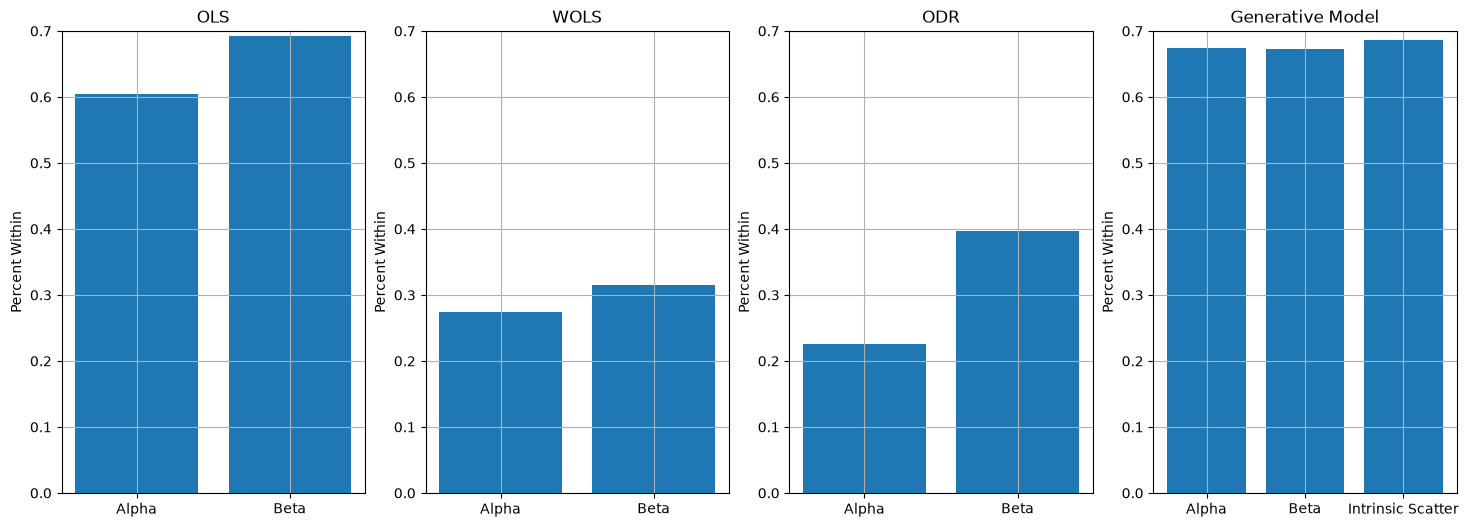

In [401]:
#Coverage
true_intercept = alpha_true * (mu_true - 9.5) + beta_true

OLS_alph_hi = OLS_slopes.T[0] + OLS_slopes.T[3]
OLS_alph_lo = OLS_slopes.T[0] - OLS_slopes.T[3]
OLS_in = np.where((OLS_alph_lo < alpha_true) & (alpha_true < OLS_alph_hi))
OLS_a_ratio = len(OLS_slopes[OLS_in]) / 2000

OLS_beta_hi = OLS_slopes.T[1] + OLS_slopes.T[2]
OLS_beta_lo = OLS_slopes.T[1] - OLS_slopes.T[2]
OLS_in = np.where((OLS_beta_lo < true_intercept) & (true_intercept < OLS_beta_hi))
OLS_b_ratio = len(OLS_slopes[OLS_in]) / 2000

WOLS_alph_hi = WOLS_slopes.T[0] + WOLS_slopes.T[3]
WOLS_alph_lo = WOLS_slopes.T[0] - WOLS_slopes.T[3]
WOLS_in = np.where((WOLS_alph_lo < alpha_true) & (alpha_true < WOLS_alph_hi))
WOLS_a_ratio = len(WOLS_slopes[WOLS_in]) / 2000

WOLS_beta_hi = WOLS_slopes.T[1] + WOLS_slopes.T[2]
WOLS_beta_lo = WOLS_slopes.T[1] - WOLS_slopes.T[2]
WOLS_in = np.where((WOLS_beta_lo < true_intercept) & (true_intercept < WOLS_beta_hi))
WOLS_b_ratio = len(OLS_slopes[WOLS_in]) / 2000

ODR_alph_hi = ODR_slopes.T[0] + ODR_slopes.T[2]
ODR_alph_lo = ODR_slopes.T[0] - ODR_slopes.T[2]
ODR_in = np.where((ODR_alph_lo < alpha_true) & (alpha_true < ODR_alph_hi))
ODR_a_ratio = len(ODR_slopes[ODR_in]) / 2000

ODR_beta_hi = ODR_slopes.T[1] + ODR_slopes.T[3]
ODR_beta_lo = ODR_slopes.T[1] - ODR_slopes.T[3]
ODR_in = np.where((ODR_beta_lo < true_intercept) & (true_intercept < ODR_beta_hi))
ODR_b_ratio = len(ODR_slopes[ODR_in]) / 2000

gen_alph_hi = gen_slopes[:, 0, 0] + gen_slopes[:, 1, 0]
gen_alph_lo = gen_slopes[:, 0, 0] - gen_slopes[:, 1, 0]
gen_in = np.where((gen_alph_lo < alpha_true) & (alpha_true < gen_alph_hi))
gen_a_ratio = len(gen_slopes[gen_in]) / 2000

gen_beta_hi = gen_slopes[:, 0, 1] + gen_slopes[:, 1, 1]
gen_beta_lo = gen_slopes[:, 0, 1] - gen_slopes[:, 1, 1]
gen_in = np.where((gen_beta_lo < beta_true) & (beta_true < gen_beta_hi))
gen_b_ratio = len(gen_slopes[gen_in]) / 2000

gen_sigma = np.exp(gen_slopes[:, 0, 2])

gen_sig_i_hi = gen_sigma + (gen_slopes[:, 1, 2])
gen_sig_i_lo = gen_sigma - (gen_slopes[:, 1, 2])
gen_in = np.where((gen_sig_i_lo < sigma_int_true) & (sigma_int_true < gen_sig_i_hi))
gen_sig_i_ratio = len(gen_slopes[gen_in]) / 2000

plt.figure(figsize = (18, 6))
plt.subplot(1, 4, 1)
plt.bar(['Alpha', 'Beta'], [OLS_a_ratio, OLS_b_ratio])
plt.title('OLS')
plt.ylabel('Percent Within')
plt.grid()
plt.ylim([0, .7])

plt.subplot(1, 4, 2)
plt.bar(['Alpha', 'Beta'], [WOLS_a_ratio, WOLS_b_ratio])
plt.title('WOLS')
plt.ylabel('Percent Within')
plt.grid()
plt.ylim([0, .7])

plt.subplot(1, 4, 3)
plt.bar(['Alpha', 'Beta'], [ODR_a_ratio, ODR_b_ratio])
plt.title('ODR')
plt.ylabel('Percent Within')
plt.grid()
plt.ylim([0, .7])

plt.subplot(1, 4, 4)
plt.bar(['Alpha', 'Beta', 'Intrinsic Scatter'], [gen_a_ratio, gen_b_ratio, gen_sig_i_ratio])
plt.title('Generative Model')
plt.ylabel('Percent Within')
plt.grid()
plt.ylim([0, .7])

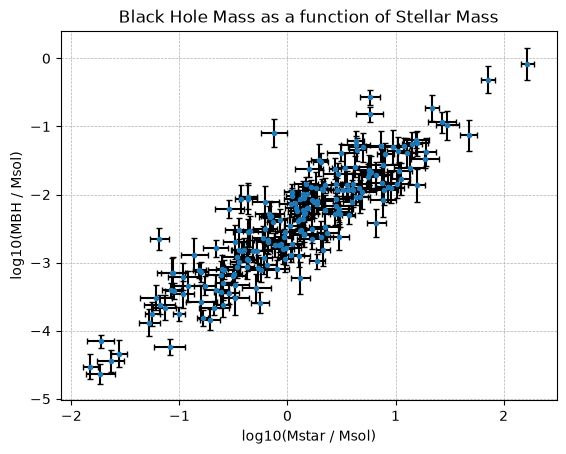

In [386]:
#50%
N = 200

# latent (true) values
x_true = np.random.normal(mu_true, tau_true, N)

y_true = (
    alpha_true * (x_true - 9.5)
    + beta_true
    + np.random.normal(0, sigma_int_true, N)
)

# measurement uncertainties
xerr = np.random.uniform(0.05, 0.15, N)
yerr = np.random.uniform(0.10, 0.25, N)

# observed values
x = x_true + np.random.normal(0, xerr)
y = y_true + np.random.normal(0, yerr)

plt.errorbar(x, y, xerr = xerr, yerr = yerr, fmt = '.', ecolor = 'black', capsize = 2)
plt.title('Black Hole Mass as a function of Stellar Mass')
plt.xlabel('log10(Mstar / Msol)')
plt.ylabel('log10(MBH / Msol)')
plt.grid(linestyle = '--', linewidth = 0.5)

In [387]:
theta0 = [1.05, 7.9, np.log(0.3), 0, np.log(.7)]

result = so.minimize(neg2logL_gen, x0 = theta0, args = (x, y, xerr + .5 * xerr, yerr + .5 * yerr), method = 'Nelder-Mead')
result.x

array([ 1.04622356,  7.46299808, -1.15556745,  0.07244636, -0.34535488])

In [392]:
H = nd.Hessian(lambda p: neg2logL_gen(p, x, y, xerr, yerr))(result.x)
Cov = 2 * np.linalg.inv(H)
uncertainty = np.sqrt(np.diag(Cov))

sigma_intr_uncert = np.exp(log_intr_s_opt) * uncertainty[2]
Tau_uncert = np.exp(log_tau_opt) * uncertainty[4]

uncertainty = [uncertainty[0], uncertainty[1], sigma_intr_uncert, uncertainty[3], Tau_uncert]

print(f'Alpha: {result.x[0]:.3f} \u00B1 {uncertainty[0]:.3f}')
print(f'Beta: {result.x[1]:.3f} \u00B1 {uncertainty[1]:.3f}')
print(f'Intrinsic Scatter: {np.exp(result.x[2]):.3f} \u00B1 {uncertainty[2]:.3f}')

Alpha: 1.046 ± 0.038
Beta: 7.463 ± 0.363
Intrinsic Scatter: 0.315 ± 0.018


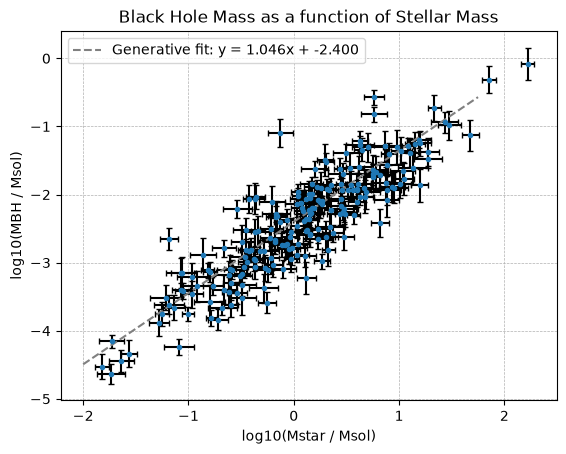

In [393]:
a_opt, B_opt, log_intr_s_opt, mu_opt, log_tau_opt = result.x  

x_gen_slope = np.linspace(-2, 1.75, 1000)
gen_intercept = a_opt * (mu_opt - 9.5) + B_opt
y_gen_slope = a_opt * x_gen_slope + gen_intercept

plt.errorbar(x, y, xerr = xerr, yerr = yerr, fmt = '.', ecolor = 'black', capsize = 2)
plt.title('Black Hole Mass as a function of Stellar Mass')
plt.xlabel('log10(Mstar / Msol)')
plt.ylabel('log10(MBH / Msol)')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.plot(x_gen_slope, y_gen_slope, color = 'grey', linestyle = '--', label = f'Generative fit: y = {a_opt:.3f}x + {gen_intercept:.3f}')
plt.legend()

Alpha: 1.083 ± 0.025
Beta: 7.811 ± 0.248
Intrinsic Scatter: 0.296 ± 0.022
mu: -0.241 ± 0.072
Tau: 1.014 ± 0.051


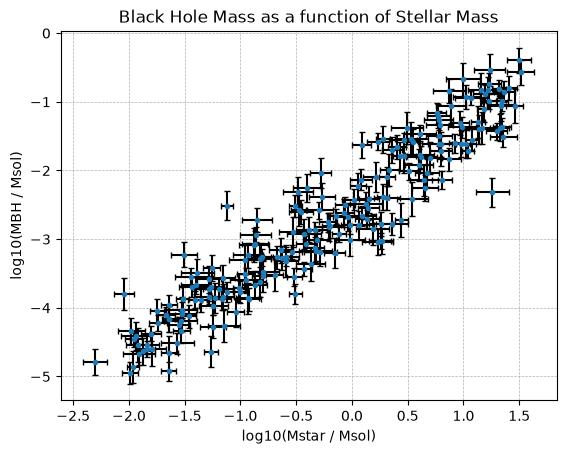

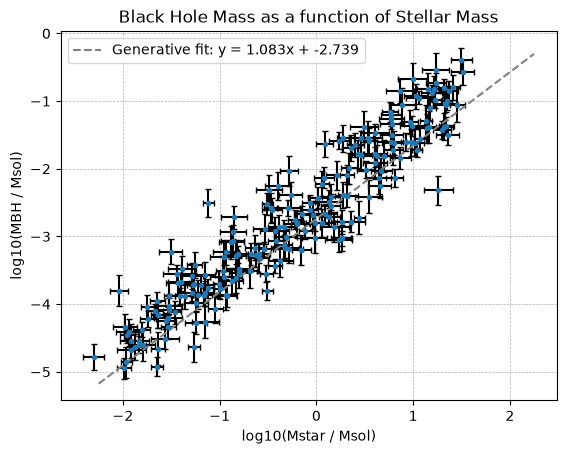

In [405]:
#Linear
N = 200

# latent (true) values
x_true = np.linspace(-2, 1.5, N)

y_true = (
    alpha_true * (x_true - 9.5)
    + beta_true
    + np.random.normal(0, sigma_int_true, N)
)

# measurement uncertainties
xerr = np.random.uniform(0.05, 0.15, N)
yerr = np.random.uniform(0.10, 0.25, N)

# observed values
x = x_true + np.random.normal(0, xerr)
y = y_true + np.random.normal(0, yerr)

plt.figure(1)
plt.errorbar(x, y, xerr = xerr, yerr = yerr, fmt = '.', ecolor = 'black', capsize = 2)
plt.title('Black Hole Mass as a function of Stellar Mass')
plt.xlabel('log10(Mstar / Msol)')
plt.ylabel('log10(MBH / Msol)')
plt.grid(linestyle = '--', linewidth = 0.5)

theta0 = [1.05, 7.9, np.log(0.3), 0, np.log(.7)]

result = so.minimize(neg2logL_gen, x0 = theta0, args = (x, y, xerr, yerr), method = 'Nelder-Mead')
H = nd.Hessian(lambda p: neg2logL_gen(p, x, y, xerr, yerr))(result.x)
Cov = 2 * np.linalg.inv(H)
uncertainty = np.sqrt(np.diag(Cov))

sigma_intr_uncert = np.exp(log_intr_s_opt) * uncertainty[2]
Tau_uncert = np.exp(log_tau_opt) * uncertainty[4]

uncertainty = [uncertainty[0], uncertainty[1], sigma_intr_uncert, uncertainty[3], Tau_uncert]

print(f'Alpha: {result.x[0]:.3f} \u00B1 {uncertainty[0]:.3f}')
print(f'Beta: {result.x[1]:.3f} \u00B1 {uncertainty[1]:.3f}')
print(f'Intrinsic Scatter: {np.exp(result.x[2]):.3f} \u00B1 {uncertainty[2]:.3f}')
print(f'mu: {result.x[3]:.3f} \u00B1 {uncertainty[3]:.3f}')
print(f'Tau: {np.exp(result.x[4]):.3f} \u00B1 {uncertainty[4]:.3f}')

a_opt, B_opt, log_intr_s_opt, mu_opt, log_tau_opt = result.x  

x_gen_slope = np.linspace(-2.25, 2.25, 1000)
gen_intercept = a_opt * (mu_opt - 9.5) + B_opt
y_gen_slope = a_opt * x_gen_slope + gen_intercept

plt.figure(2)
plt.errorbar(x, y, xerr = xerr, yerr = yerr, fmt = '.', ecolor = 'black', capsize = 2)
plt.title('Black Hole Mass as a function of Stellar Mass')
plt.xlabel('log10(Mstar / Msol)')
plt.ylabel('log10(MBH / Msol)')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.plot(x_gen_slope, y_gen_slope, color = 'grey', linestyle = '--', label = f'Generative fit: y = {a_opt:.3f}x + {gen_intercept:.3f}')
plt.legend()

Alpha: 1.088 ± 0.022
Beta: 7.864 ± 0.205
Intrinsic Scatter: 0.0398 ± 0.0002
mu: 0.047 ± 0.048
Tau: 0.677 ± 0.036


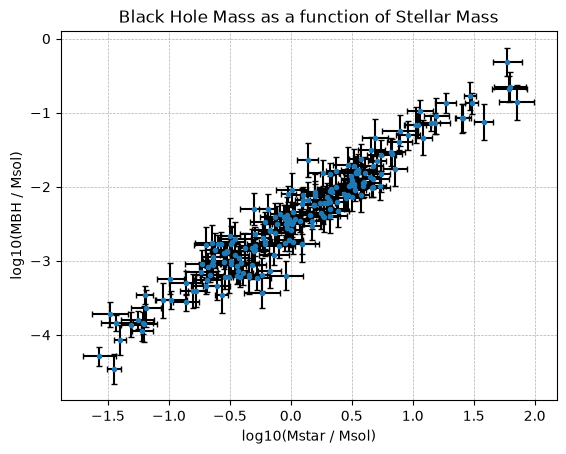

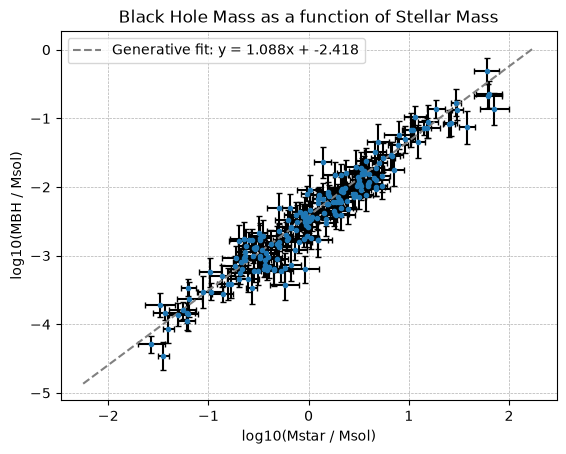

In [407]:
#Sigma Intrinsic = 0
N = 200

# latent (true) values
x_true = np.random.normal(mu_true, tau_true, N)

y_true = (
    alpha_true * (x_true - 9.5)
    + beta_true
)

# measurement uncertainties
xerr = np.random.uniform(0.05, 0.15, N)
yerr = np.random.uniform(0.10, 0.25, N)

# observed values
x = x_true + np.random.normal(0, xerr)
y = y_true + np.random.normal(0, yerr)

plt.figure(1)
plt.errorbar(x, y, xerr = xerr, yerr = yerr, fmt = '.', ecolor = 'black', capsize = 2)
plt.title('Black Hole Mass as a function of Stellar Mass')
plt.xlabel('log10(Mstar / Msol)')
plt.ylabel('log10(MBH / Msol)')
plt.grid(linestyle = '--', linewidth = 0.5)

theta0 = [1.05, 7.9, np.log(1.1), 0, np.log(.7)]

result = so.minimize(neg2logL_gen, x0 = theta0, args = (x, y, xerr, yerr), method = 'Nelder-Mead')
H = nd.Hessian(lambda p: neg2logL_gen(p, x, y, xerr, yerr))(result.x)
Cov = 2 * np.linalg.inv(H)
uncertainty = np.sqrt(np.diag(Cov))

sigma_intr_uncert = np.exp(log_intr_s_opt) * uncertainty[2]
Tau_uncert = np.exp(log_tau_opt) * uncertainty[4]

uncertainty = [uncertainty[0], uncertainty[1], sigma_intr_uncert, uncertainty[3], Tau_uncert]

print(f'Alpha: {result.x[0]:.3f} \u00B1 {uncertainty[0]:.3f}')
print(f'Beta: {result.x[1]:.3f} \u00B1 {uncertainty[1]:.3f}')
print(f'Intrinsic Scatter: {np.exp(result.x[2]):.4f} \u00B1 {uncertainty[2]:.4f}')
print(f'mu: {result.x[3]:.3f} \u00B1 {uncertainty[3]:.3f}')
print(f'Tau: {np.exp(result.x[4]):.3f} \u00B1 {uncertainty[4]:.3f}')

a_opt, B_opt, log_intr_s_opt, mu_opt, log_tau_opt = result.x  

x_gen_slope = np.linspace(-2.25, 2.25, 1000)
gen_intercept = a_opt * (mu_opt - 9.5) + B_opt
y_gen_slope = a_opt * x_gen_slope + gen_intercept

plt.figure(2)
plt.errorbar(x, y, xerr = xerr, yerr = yerr, fmt = '.', ecolor = 'black', capsize = 2)
plt.title('Black Hole Mass as a function of Stellar Mass')
plt.xlabel('log10(Mstar / Msol)')
plt.ylabel('log10(MBH / Msol)')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.plot(x_gen_slope, y_gen_slope, color = 'grey', linestyle = '--', label = f'Generative fit: y = {a_opt:.3f}x + {gen_intercept:.3f}')
plt.legend()

**WHAT THE CHECKS FOUND:**

1) I found that my model recovered the simulated data and returned a model with order of magnitude values for my fit.
2) My model found that that my generative model was unbiased, and that the OLS and WOLS were biased low while my ODR was biased high.
3) My model found that the generative model correctly predicted the right value about 68% of the time.
4) 50% increased model slope, a uniform distribution created inaccurate values for tau and mu, and a model with zero intrinsic scatter reduced tau and mu.

Since these four checks were passed, I feel confident in the capabilities of my model. 

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

*I used Copilot for this project. One of the things it got wrong was my uncertainty calcualtion. When I was writing my code, I used the liklihood function from the lecture slides to analyze my model. However, I did not realize that this liklihood model required an extra factor of 2 in the covariance to get uncertainties correct. This resulted in my model consitently getting a coverage of about ~50% for a long while even though the model was unbiased. It wasn't until I plotted my unbiased results and these histograms depicting the spread of my values that it produced the idea that my liklihood function was correct. Since I had these histograms I could visually see that my estimators were getting the correct values, and that the error had to be higher up in my code (in this case, wehre I calculated the Hessian/covariance).*

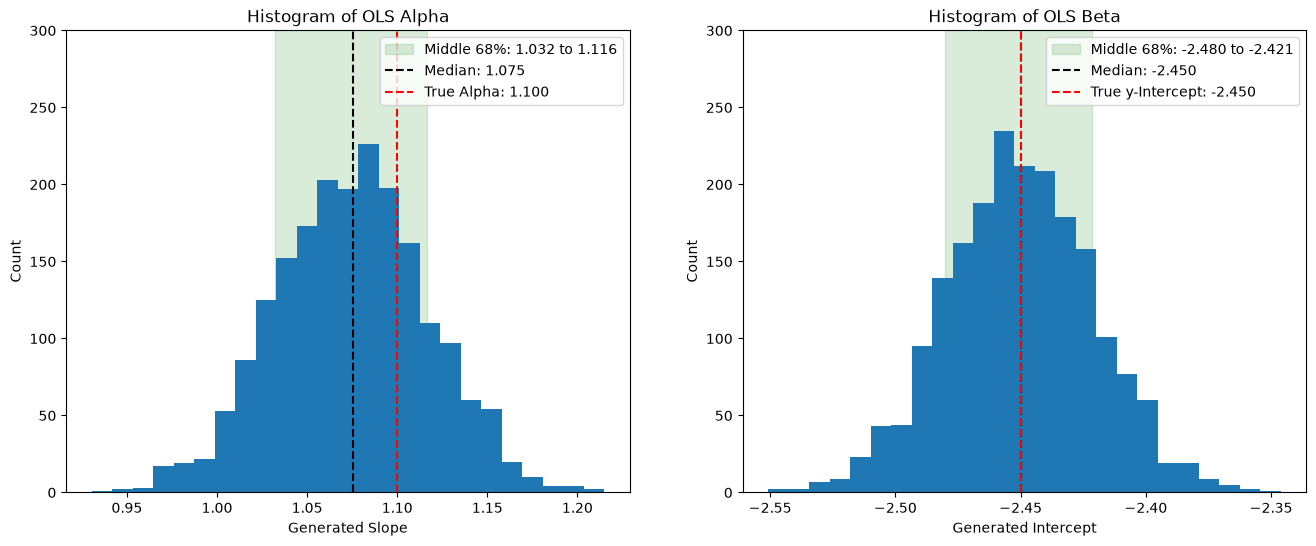

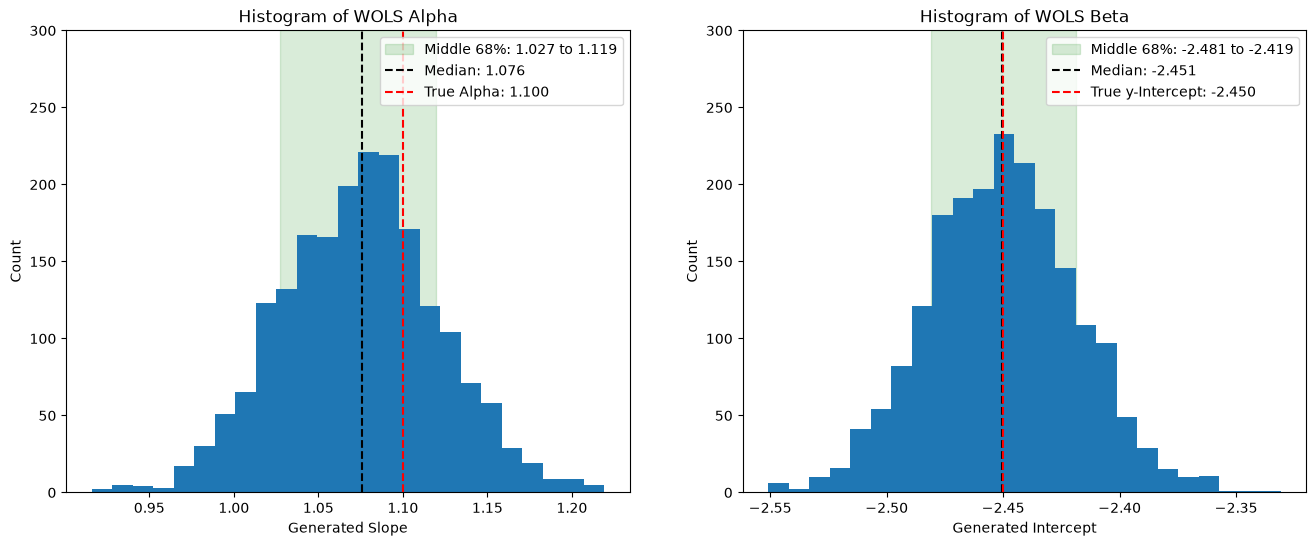

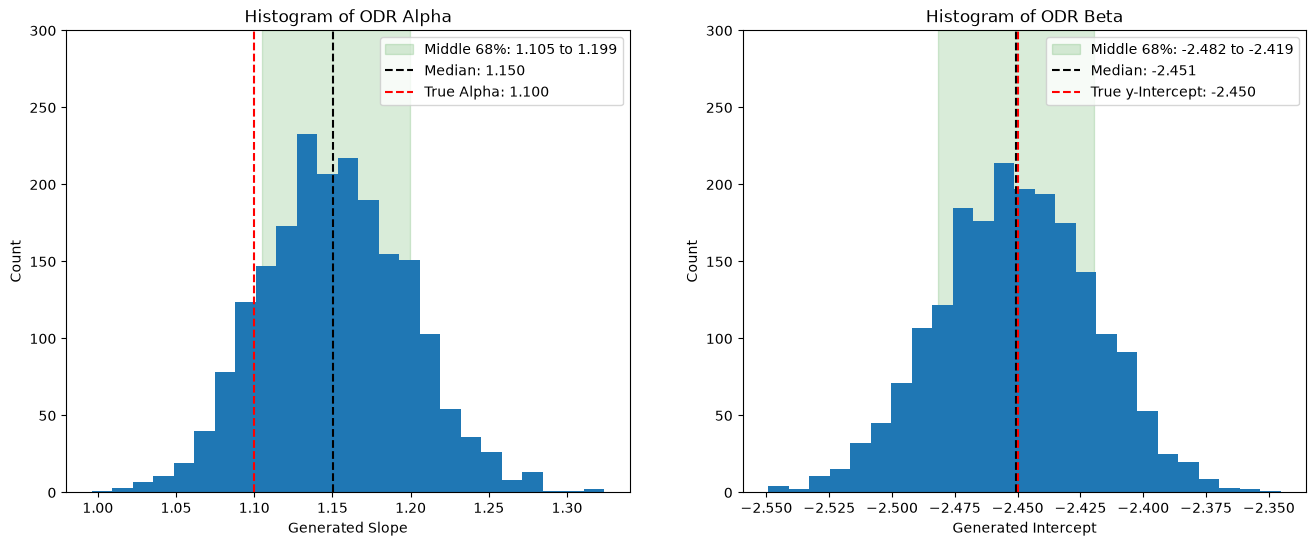

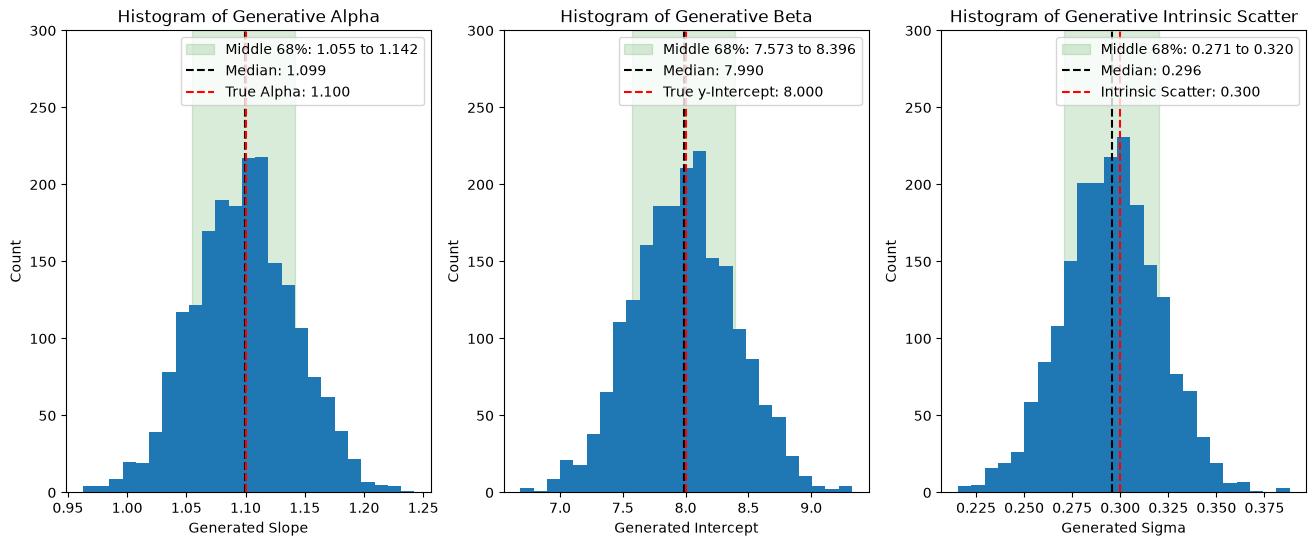

In [400]:
plt.figure(1, figsize = (16, 6))
plt.subplot(1, 2, 1)
med = np.median(OLS_slopes.T[0])

hi, lo = np.percentile(OLS_slopes.T[0], [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f}')

plt.hist(OLS_slopes.T[0], bins = 25)
plt.title('Histogram of OLS Alpha')
plt.ylabel('Count')
plt.xlabel('Generated Slope')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Median: {med:.3f}')
plt.vlines(alpha_true, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'True Alpha: {alpha_true:.3f}')
plt.ylim([0, 300])
plt.legend()

plt.subplot(1, 2, 2)
med = np.median(OLS_slopes.T[1])

hi, lo = np.percentile(OLS_slopes.T[1], [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f}')

plt.hist(OLS_slopes.T[1], bins = 25)
plt.title('Histogram of OLS Beta')
plt.ylabel('Count')
plt.xlabel('Generated Intercept')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Median: {med:.3f}')
plt.vlines(true_intercept, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'True y-Intercept: {true_intercept:.3f}')
plt.ylim([0, 300])
plt.legend()



plt.figure(2, figsize = (16, 6))
plt.subplot(1, 2, 1)
med = np.median(WOLS_slopes.T[0])

hi, lo = np.percentile(WOLS_slopes.T[0], [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f}')

plt.hist(WOLS_slopes.T[0], bins = 25)
plt.title('Histogram of WOLS Alpha')
plt.ylabel('Count')
plt.xlabel('Generated Slope')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Median: {med:.3f}')
plt.vlines(alpha_true, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'True Alpha: {alpha_true:.3f}')
plt.ylim([0, 300])
plt.legend()

plt.subplot(1, 2, 2)
med = np.median(WOLS_slopes.T[1])

hi, lo = np.percentile(WOLS_slopes.T[1], [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f}')

plt.hist(WOLS_slopes.T[1], bins = 25)
plt.title('Histogram of WOLS Beta')
plt.ylabel('Count')
plt.xlabel('Generated Intercept')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Median: {med:.3f}')
plt.vlines(true_intercept, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'True y-Intercept: {true_intercept:.3f}')
plt.ylim([0, 300])
plt.legend()



plt.figure(3, figsize = (16, 6))
plt.subplot(1, 2, 1)
med = np.median(ODR_slopes.T[0])

hi, lo = np.percentile(ODR_slopes.T[0], [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f}')

plt.hist(ODR_slopes.T[0], bins = 25)
plt.title('Histogram of ODR Alpha')
plt.ylabel('Count')
plt.xlabel('Generated Slope')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Median: {med:.3f}')
plt.vlines(alpha_true, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'True Alpha: {alpha_true:.3f}')
plt.ylim([0, 300])
plt.legend()

plt.subplot(1, 2, 2)
med = np.median(ODR_slopes.T[1])

hi, lo = np.percentile(ODR_slopes.T[1], [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f}')

plt.hist(ODR_slopes.T[1], bins = 25)
plt.title('Histogram of ODR Beta')
plt.ylabel('Count')
plt.xlabel('Generated Intercept')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Median: {med:.3f}')
plt.vlines(true_intercept, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'True y-Intercept: {true_intercept:.3f}')
plt.ylim([0, 300])
plt.legend()



plt.figure(4, figsize = (16, 6))
plt.subplot(1, 3, 1)
med = np.median(gen_slopes[:, 0, 0])

hi, lo = np.percentile(gen_slopes[:, 0, 0], [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f}')
plt.hist(gen_slopes[:, 0, 0], bins = 25)
plt.title('Histogram of Generative Alpha')
plt.ylabel('Count')
plt.xlabel('Generated Slope')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Median: {med:.3f}')
plt.vlines(alpha_true, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'True Alpha: {alpha_true:.3f}')
plt.ylim([0, 300])
plt.legend()

plt.subplot(1, 3, 2)
med = np.median(gen_slopes[:, 0, 1])

hi, lo = np.percentile(gen_slopes[:, 0, 1], [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f}')

plt.hist(gen_slopes[:, 0, 1], bins = 25)
plt.title('Histogram of Generative Beta')
plt.ylabel('Count')
plt.xlabel('Generated Intercept')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Median: {med:.3f}')
plt.vlines(beta_true, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'True y-Intercept: {beta_true:.3f}')
plt.ylim([0, 300])
plt.legend()

plt.subplot(1, 3, 3)
med = np.exp(np.median(gen_slopes[:, 0, 2]))

hi, lo = np.percentile(np.exp(gen_slopes[:, 0, 2]), [84, 16])

plt.axvspan(hi, lo, color = 'green', alpha = .15, label = f'Middle 68%: {lo:.3f} to {hi:.3f}')

plt.hist(np.exp(gen_slopes[:, 0, 2]), bins = 25)
plt.title('Histogram of Generative Intrinsic Scatter')
plt.ylabel('Count')
plt.xlabel('Generated Sigma')
plt.vlines(med, ymin = 0, ymax = 750, color = 'black', linestyle = '--', label = f'Median: {med:.3f}')
plt.vlines(sigma_int_true, ymin = 0, ymax = 750, color = 'red', linestyle = '--', label = f'Intrinsic Scatter: {sigma_int_true:.3f}')
plt.ylim([0, 300])
plt.legend()